In [146]:
import os
import pandas as pd

# Directory containing the .pkl files
directory = r'Z:\Uni\Master_Astronomy\GitHub\JAX_deprojection\SVI_notebooks\pqe\table'
directory2 = r'Z:\Uni\Master_Astronomy\GitHub\JAX_deprojection\SVI_notebooks\pqe_900\table'

# Initialize an empty list to store DataFrames
dataframes = []

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.pkl') and filename != 'combined_table.pkl':
        filepath = os.path.join(directory, filename)
        df = pd.read_pickle(filepath)  # Load the DataFrame
        dataframes.append(df)  # Append to the list

# Iterate over all files in the directory
for filename in os.listdir(directory2):
    if filename.endswith('.pkl') and filename != 'combined_table.pkl':
        filepath = os.path.join(directory2, filename)
        df = pd.read_pickle(filepath)  # Load the DataFrame
        dataframes.append(df)  # Append to the list

# Combine all DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)
combined_df['Number of free parameters'] = combined_df['Model Name'].apply(lambda x: x.count('_') + 1)

# Add a new column that checks for the presence of 'i', 'phi', or 'theta' in 'Model Name'
combined_df['Free viewing angles'] = combined_df['Model Name'].apply(
    lambda x: 'Yes' if any(sub in x for sub in ['i', 'phi', 'theta']) else 'No'
)

# Add a new column that checks for the presence of 'i', 'phi', or 'theta' in 'Model Name'
combined_df['Only radially dependent'] = combined_df['Model Name'].apply(
    lambda x: 'Yes' if x == 'p(r)_q(r)_e(r)' else 'No'
)

# Add a new column that checks for the presence of 'i', 'phi', or 'theta' in 'Model Name'
combined_df['Constant inputs'] = combined_df['Input p'].apply(
    lambda x: 'Yes' if 'const' in x  else 'No'
)

# Add a new column that sums the specified score columns
combined_df['input_recovery_score'] = combined_df[['p_score', 'q_score', 'e_score', 'rho0_score', 's_score', 
                        'a_score', 'b_score', 'i_score', 'phi_score', 'theta_score']].sum(axis=1)


# Display the combined DataFrame
#print(combined_df)

# Optionally save the combined DataFrame to a new .pkl file
output_path = os.path.join(directory, 'combined_table.pkl')
combined_df.to_pickle(output_path)

In [147]:
pd.set_option('display.max_rows', 150) 

In [148]:
# histograms of of the image scores and maybe total scores
# by number of parameters and inputs for p
# number of steps
# go to 900 steps
# see email prash
# split data set more to make histogramms clearer
# free viewing angles and not, only radially dependent params and rest, only constant inputs for pqe and more complex inputfunctions, conmpare const high vs const low, linear incline vs linear decline, also flat and steep poly
# calculate input recovery score
# maybe 2d histogramms using img and ir scores

# try rotationby 90 degrees and see if q is fit better


In [149]:
combined_df = combined_df.sort_values(by='total_score', ascending=True)
combined_df[['Model Name','Steps','Input p','img_score','input_recovery_score','total_score','Number of free parameters','Free viewing angles','Only radially dependent','Constant inputs']]

,Model Name,Steps,Input p,img_score,input_recovery_score,total_score,Number of free parameters,Free viewing angles,Only radially dependent,Constant inputs
104,p(r)_q(r)_e(r),900,const_low,411.931763,0.283752,412.215515,3,No,Yes,Yes
120,p(r)_q(r)_e(r),900,linear_incline,412.439514,0.390445,412.829959,3,No,Yes,No
136,p(r)_q(r)_e(r),900,poly_steep,412.724243,0.440629,413.164872,3,No,Yes,No
123,p(r)_q(r)_e(r)_rho0_s_a,900,linear_incline,410.888702,2.615654,413.504357,6,No,No,No
124,p(r)_q(r)_e(r)_rho0_s_a_b,900,linear_incline,411.402161,2.640847,414.043008,7,No,No,No
139,p(r)_q(r)_e(r)_rho0_s_a,900,poly_steep,412.149323,2.248059,414.397381,6,No,No,No
128,p(r)_q(r)_e(r),900,poly_flat,414.130188,0.375685,414.505873,3,No,Yes,No
115,p(r)_q(r)_e(r)_rho0_s_a,900,linear_decline,412.678467,1.876564,414.555031,6,No,No,No
116,p(r)_q(r)_e(r)_rho0_s_a_b,900,linear_decline,412.563965,2.019902,414.583867,7,No,No,No
131,p(r)_q(r)_e(r)_rho0_s_a,900,poly_flat,412.855927,1.895020,414.750946,6,No,No,No


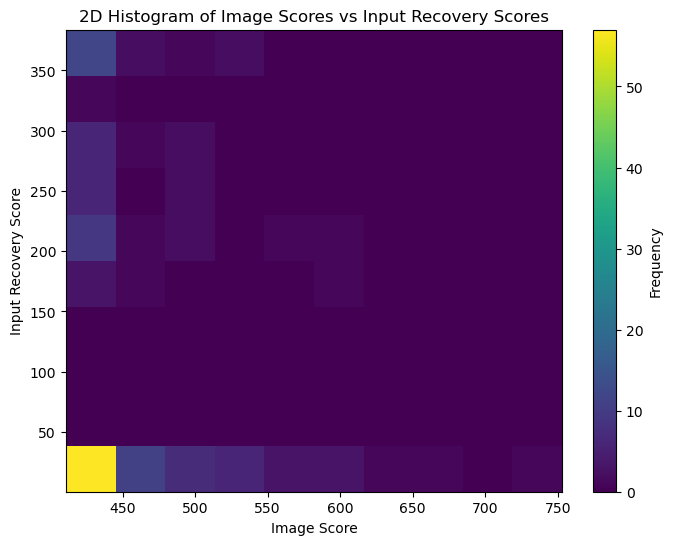

In [164]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
plt.hist2d(
    combined_df['img_score'], 
    combined_df['input_recovery_score'], 
    bins=(10, 10),  # Number of bins for x and y axes
    cmap='viridis'  # Colormap for the 2D histogram
)
plt.colorbar(label='Frequency')
plt.title('2D Histogram of Image Scores vs Input Recovery Scores')
plt.xlabel('Image Score')
plt.ylabel('Input Recovery Score')
plt.show()

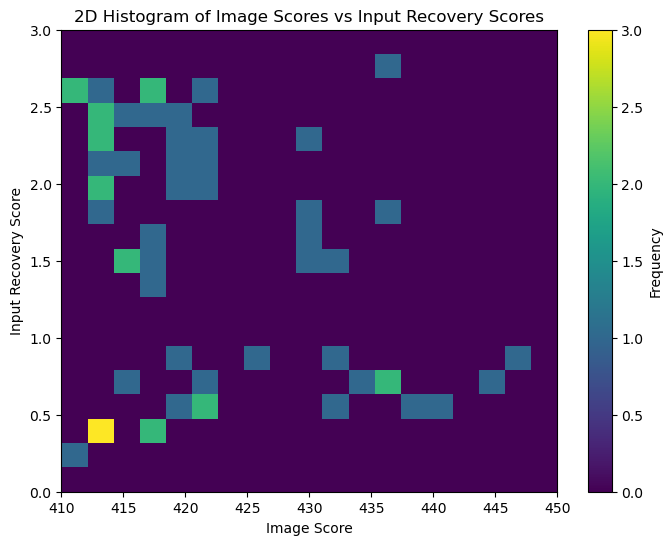

In [ ]:
# Define bin ranges for x (img_score) and y (input_recovery_score)
x_bins = np.linspace(410, 450, 20)  # 40 bins from 300 to 450
y_bins = np.linspace(0, 3, 20)    # 40 bins from 0 to 50

# 2D histogram for img_score and input_recovery_score
plt.figure(figsize=(8, 6))
plt.hist2d(
    combined_df['img_score'], 
    combined_df['input_recovery_score'], 
    bins=[x_bins, y_bins],  # Use the defined bin ranges
    cmap='viridis'          # Colormap for the 2D histogram
)
plt.colorbar(label='Frequency')
plt.title('2D Histogram of Image Scores vs Input Recovery Scores')
plt.xlabel('Image Score')
plt.ylabel('Input Recovery Score')
plt.xlim(410, 450)  # Set x-axis limits
plt.ylim(0, 3)     # Set y-axis limits
plt.show()

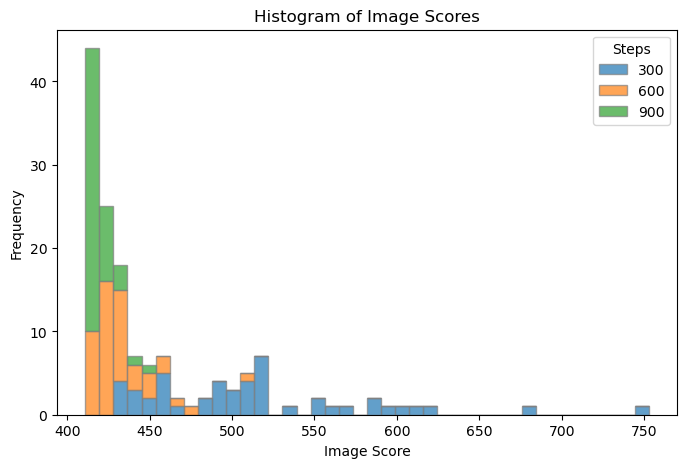

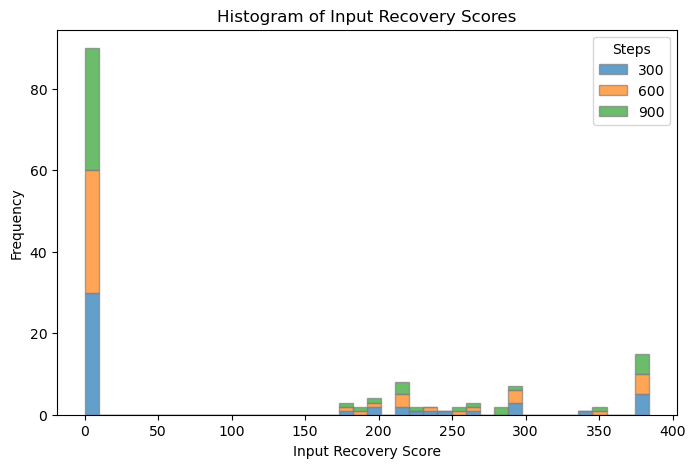

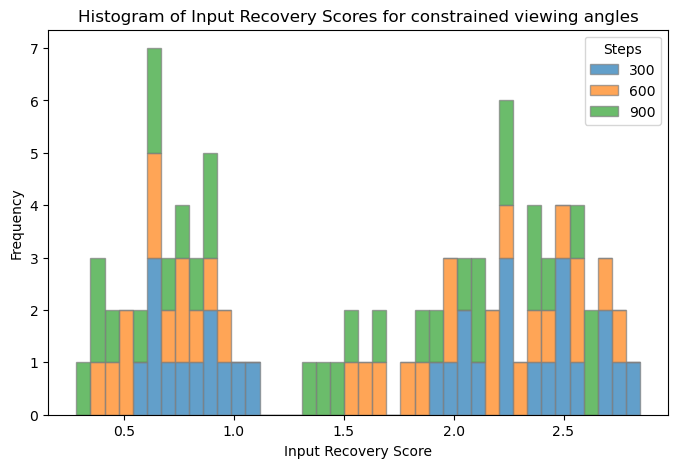

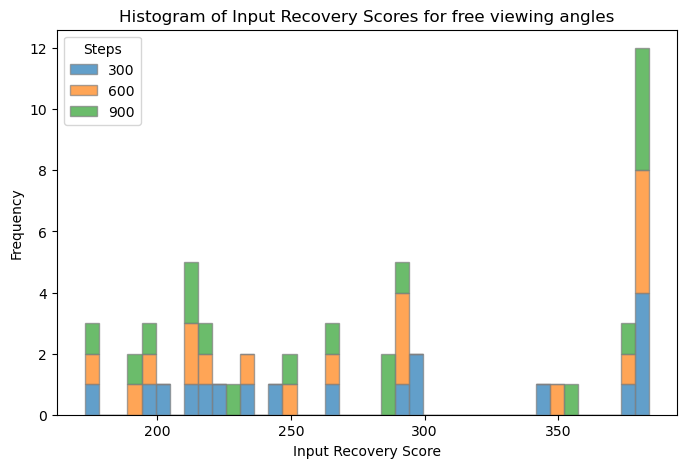

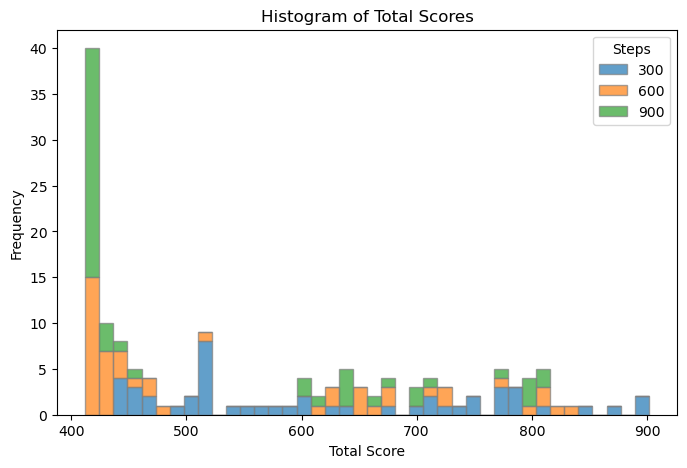

In [ ]:

# Prepare data for barstacked histogram
steps_unique = sorted(combined_df['Steps'].unique())
data = [combined_df[combined_df['Steps'] == step]['img_score'] for step in steps_unique]

# Stacked histogram for img_score
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Image Scores')
plt.xlabel('Image Score')
plt.ylabel('Frequency')
plt.legend(title='Steps')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Steps'] == step)]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Steps')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Steps'] == step) & (combined_df['Free viewing angles'] == 'No')]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for constrained viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Steps')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Steps'] == step) & (combined_df['Free viewing angles'] == 'Yes')]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for free viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Steps')
plt.show()

# Stacked histogram for total_score
data = [combined_df[combined_df['Steps'] == step]['total_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.legend(title='Steps')
plt.show()



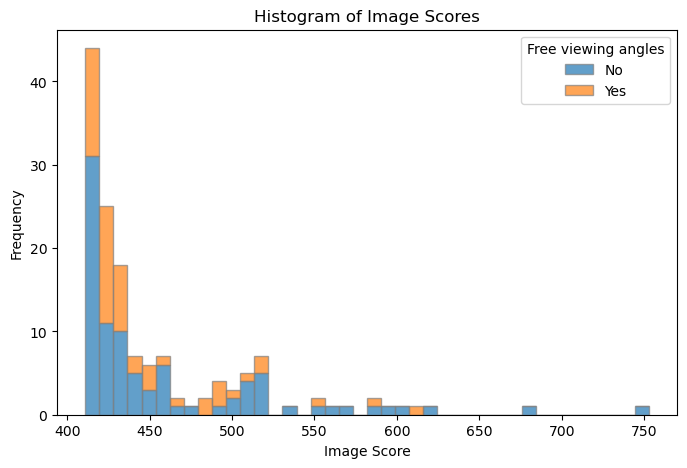

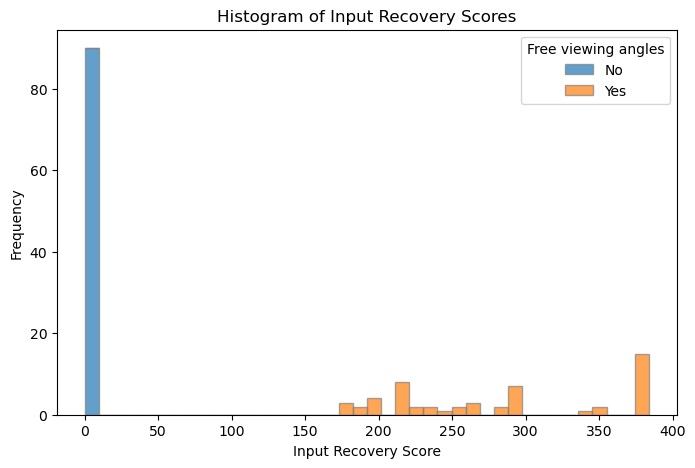

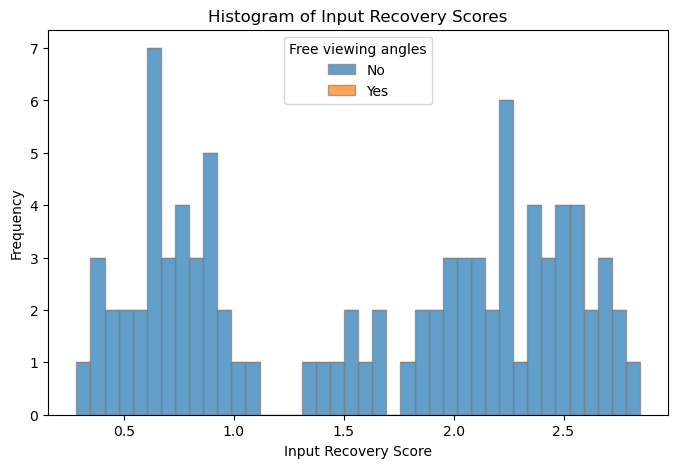

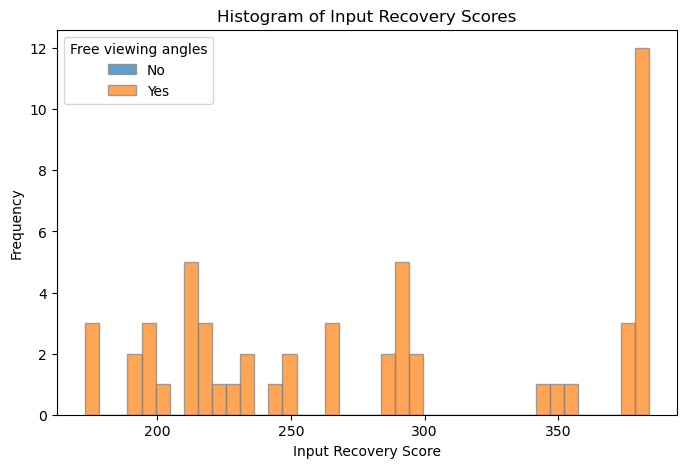

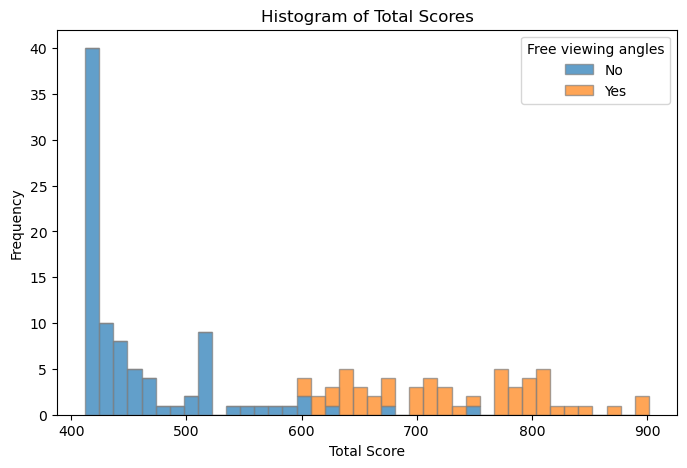

In [174]:
# Prepare data for barstacked histogram
steps_unique = combined_df['Free viewing angles'].unique()
data = [combined_df[combined_df['Free viewing angles'] == step]['img_score'] for step in steps_unique]

# Stacked histogram for img_score
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Image Scores')
plt.xlabel('Image Score')
plt.ylabel('Frequency')
plt.legend(title='Free viewing angles')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Free viewing angles'] == step)]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Free viewing angles')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Free viewing angles'] == step) & (combined_df['Free viewing angles'] == 'No')]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Free viewing angles')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Free viewing angles'] == step) & (combined_df['Free viewing angles'] == 'Yes')]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Free viewing angles')
plt.show()

# Stacked histogram for total_score
data = [combined_df[combined_df['Free viewing angles'] == step]['total_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.legend(title='Free viewing angles')
plt.show()

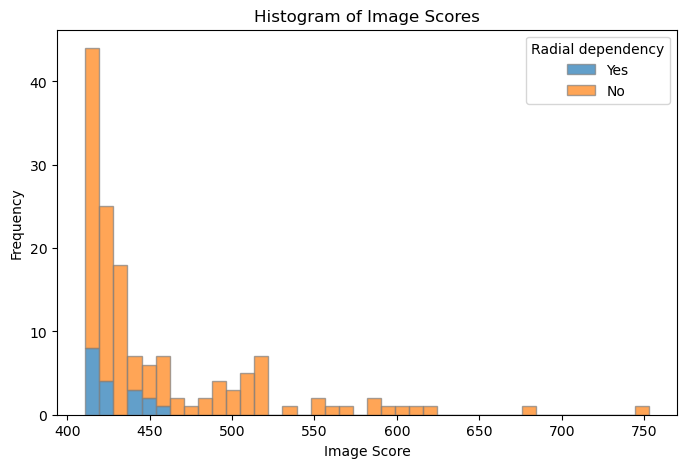

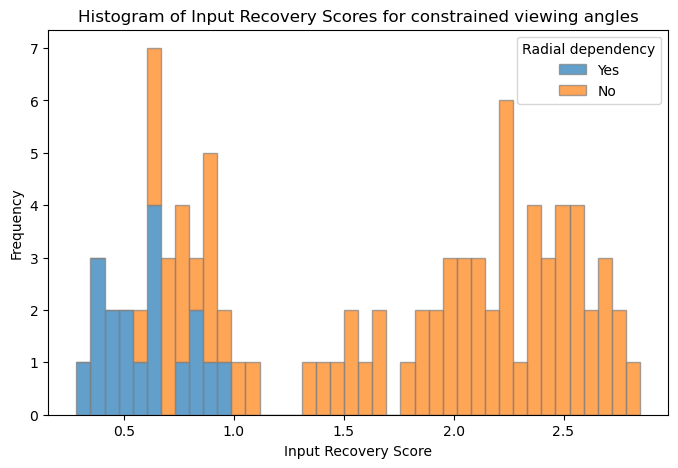

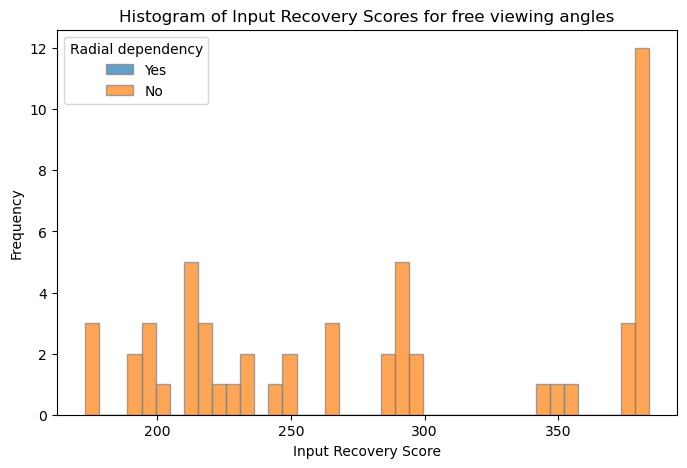

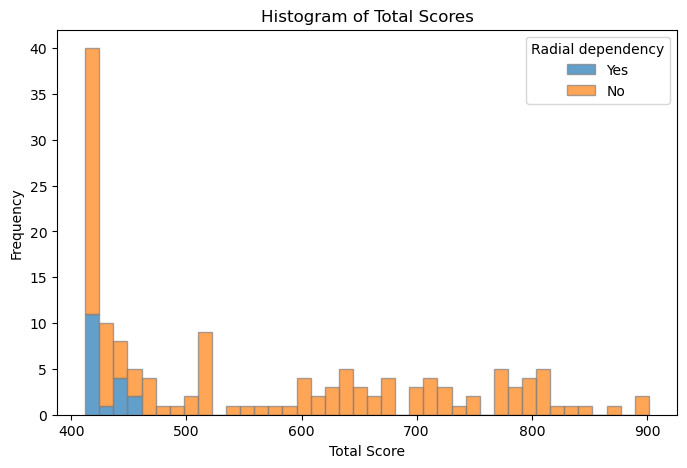

In [ ]:
# Prepare data for barstacked histogram
steps_unique = combined_df['Only radially dependent'].unique()
data = [combined_df[combined_df['Only radially dependent'] == step]['img_score'] for step in steps_unique]

# Stacked histogram for img_score
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Image Scores')
plt.xlabel('Image Score')
plt.ylabel('Frequency')
plt.legend(title='Radial dependency')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Only radially dependent'] == step)]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Radial dependency')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Only radially dependent'] == step) & (combined_df['Free viewing angles'] == 'No')]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for constrained viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Radial dependency')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Only radially dependent'] == step) & (combined_df['Free viewing angles'] == 'Yes')]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for free viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Radial dependency')
plt.show()

# Stacked histogram for total_score
data = [combined_df[combined_df['Only radially dependent'] == step]['total_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.legend(title='Radial dependency')
plt.show()

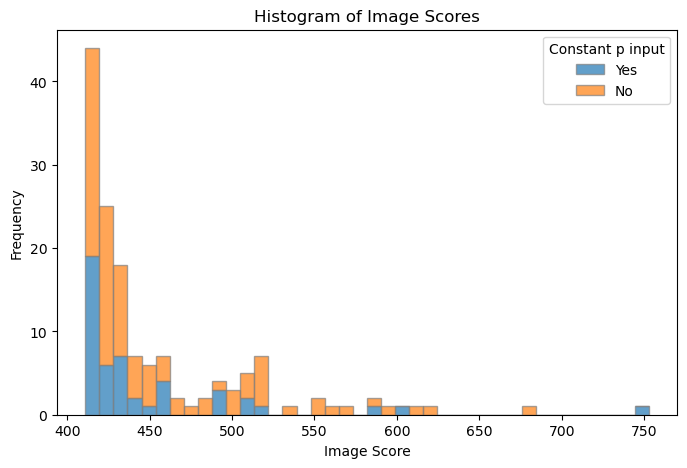

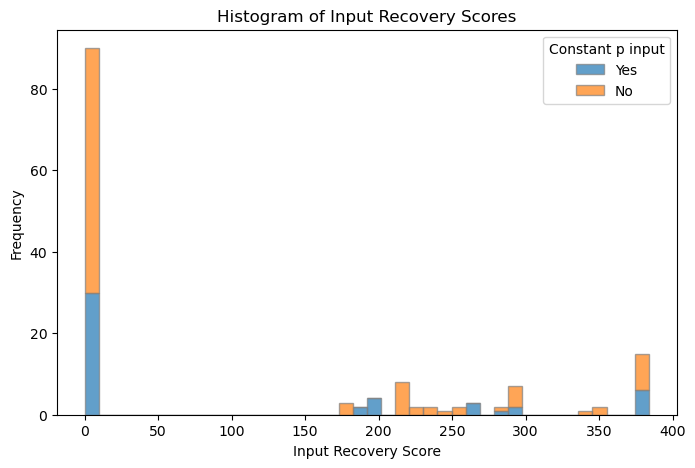

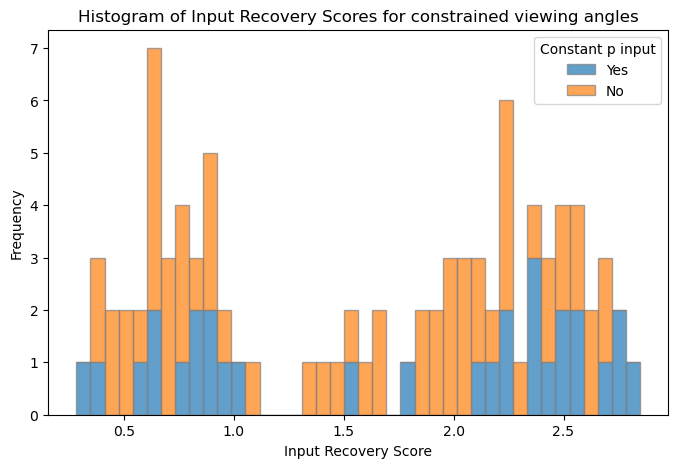

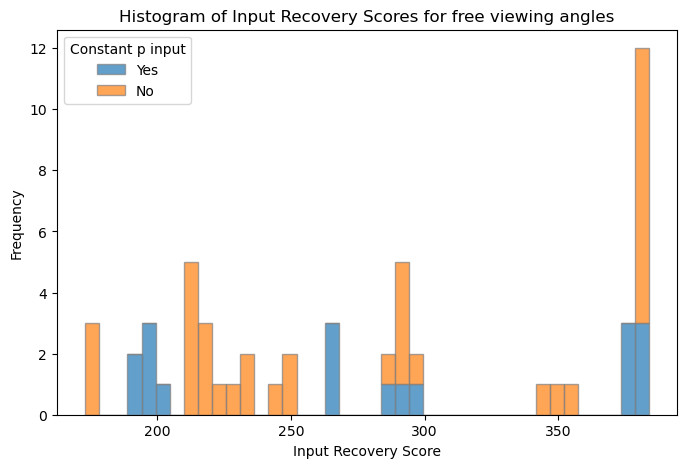

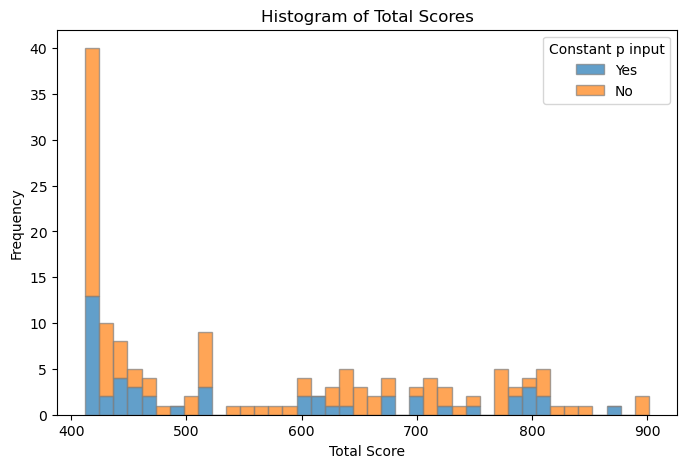

In [175]:
# Prepare data for barstacked histogram
steps_unique = combined_df['Constant inputs'].unique()
data = [combined_df[combined_df['Constant inputs'] == step]['img_score'] for step in steps_unique]

# Stacked histogram for img_score
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Image Scores')
plt.xlabel('Image Score')
plt.ylabel('Frequency')
plt.legend(title='Constant p input')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Constant inputs'] == step)]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Constant p input')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Constant inputs'] == step) & (combined_df['Free viewing angles'] == 'No')]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for constrained viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Constant p input')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Constant inputs'] == step) & (combined_df['Free viewing angles'] == 'Yes')]['input_recovery_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for free viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Constant p input')
plt.show()

# Stacked histogram for total_score
data = [combined_df[combined_df['Constant inputs'] == step]['total_score'] for step in steps_unique]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{step}' for step in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.legend(title='Constant p input')
plt.show()

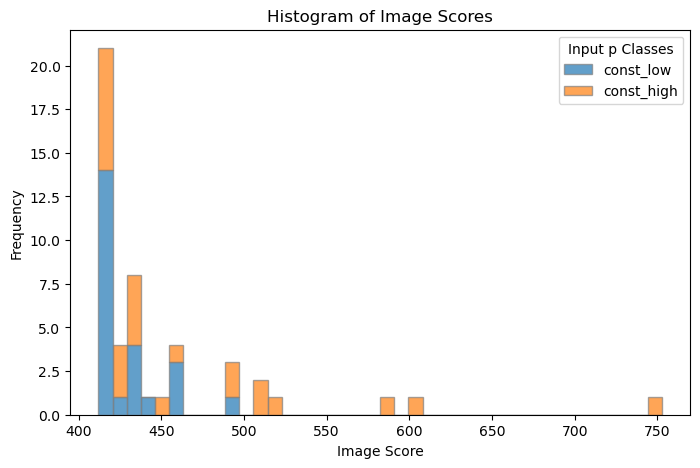

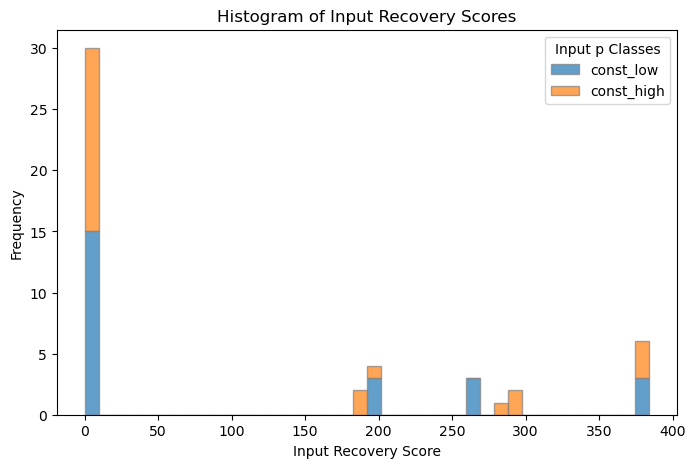

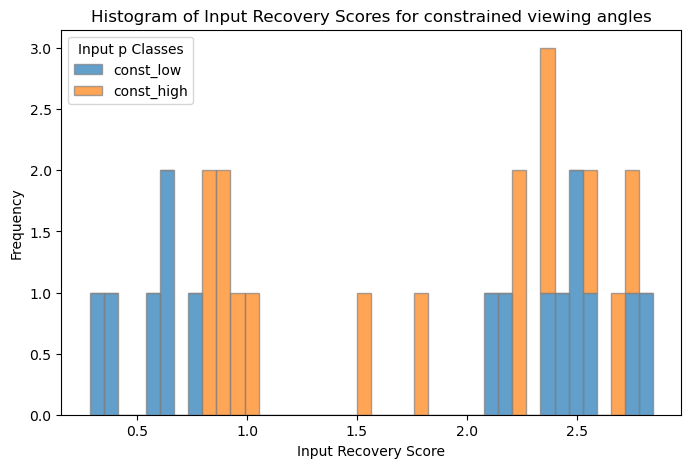

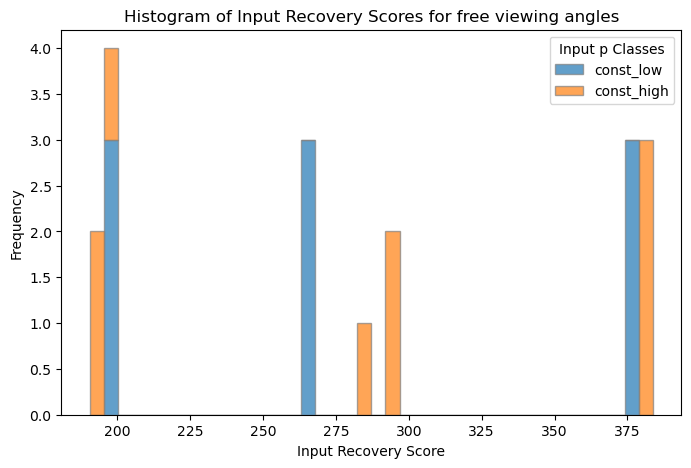

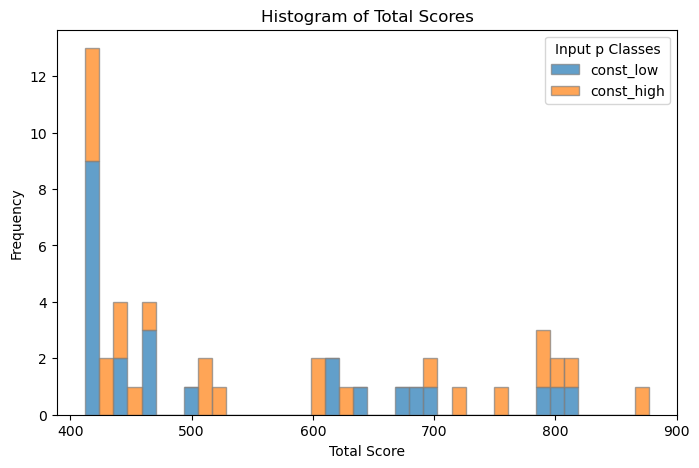

In [176]:
# Prepare data for barstacked histogram
input_classes = ['const_low', 'const_high']
data = [combined_df[combined_df['Input p'] == input_class]['img_score'] for input_class in input_classes]

# Stacked histogram for img_score
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Image Scores')
plt.xlabel('Image Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Input p'] == input_class)]['input_recovery_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Input p'] == input_class) & (combined_df['Free viewing angles'] == 'No')]['input_recovery_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for constrained viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Input p'] == input_class) & (combined_df['Free viewing angles'] == 'Yes')]['input_recovery_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for free viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[combined_df['Input p'] == input_class]['total_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

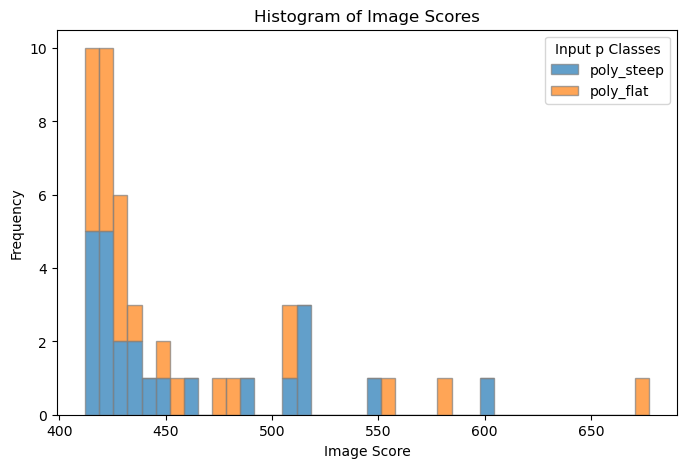

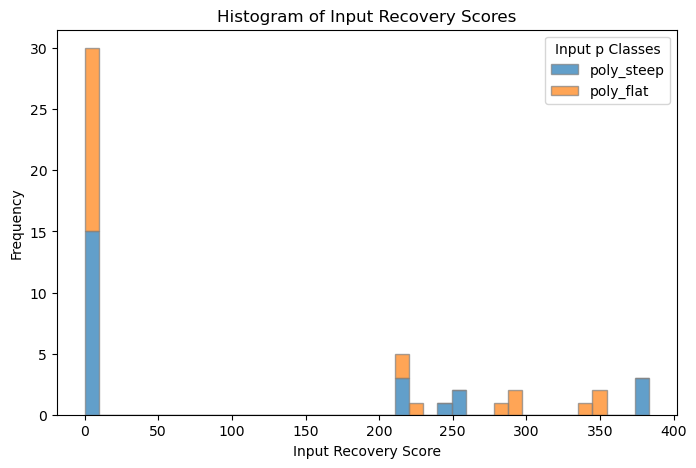

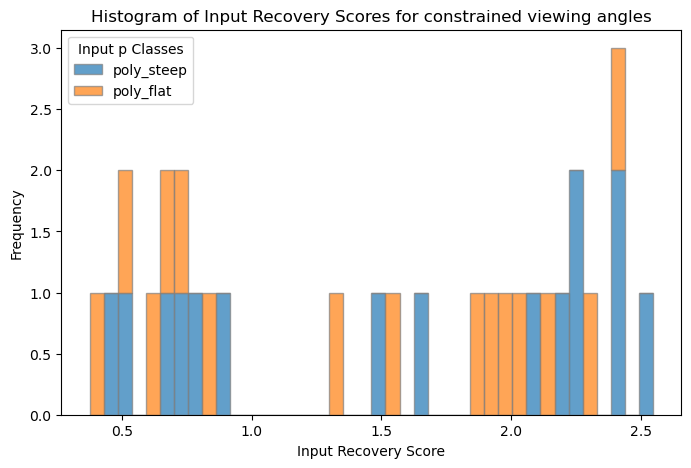

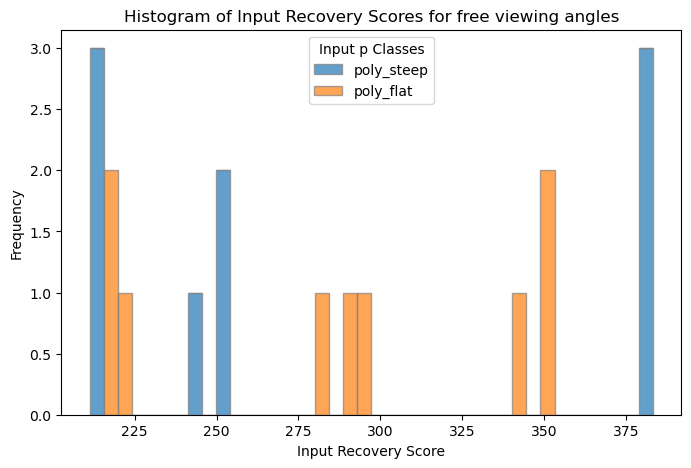

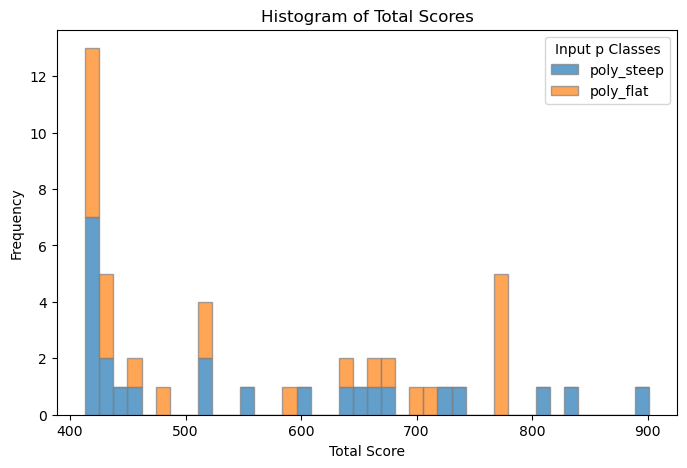

In [177]:
# Prepare data for barstacked histogram
input_classes = ['poly_steep', 'poly_flat']
data = [combined_df[combined_df['Input p'] == input_class]['img_score'] for input_class in input_classes]

# Stacked histogram for img_score
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Image Scores')
plt.xlabel('Image Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Input p'] == input_class)]['input_recovery_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Input p'] == input_class) & (combined_df['Free viewing angles'] == 'No')]['input_recovery_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for constrained viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Input p'] == input_class) & (combined_df['Free viewing angles'] == 'Yes')]['input_recovery_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for free viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[combined_df['Input p'] == input_class]['total_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

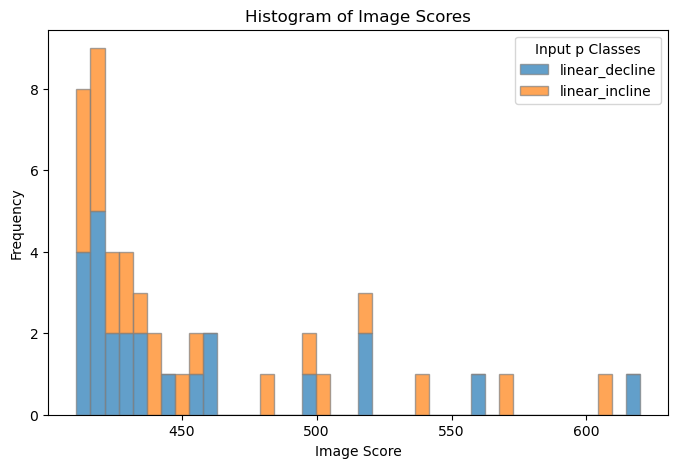

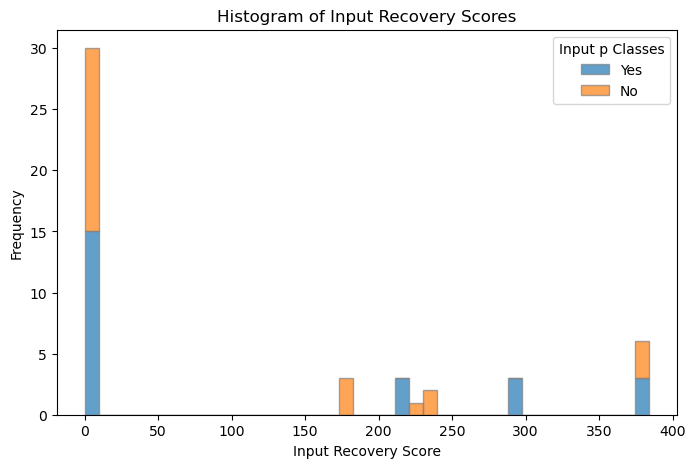

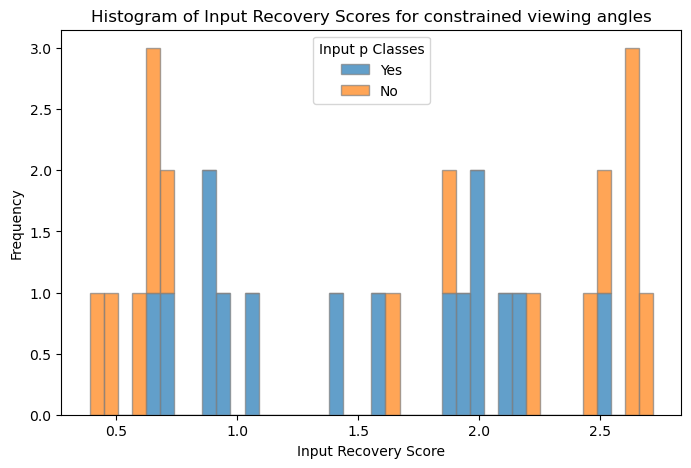

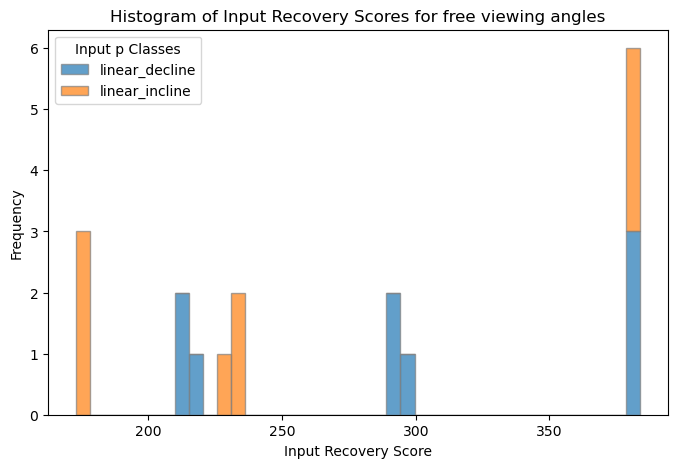

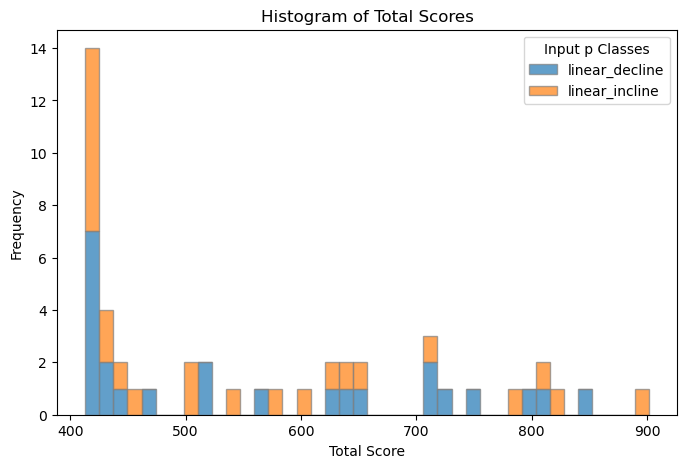

In [178]:
# Prepare data for barstacked histogram
input_classes = ['linear_decline', 'linear_incline']
data = [combined_df[combined_df['Input p'] == input_class]['img_score'] for input_class in input_classes]

# Stacked histogram for img_score
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Image Scores')
plt.xlabel('Image Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Input p'] == input_class)]['input_recovery_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()


# Stacked histogram for total_score
data = [combined_df[(combined_df['Input p'] == input_class) & (combined_df['Free viewing angles'] == 'No')]['input_recovery_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in steps_unique], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for constrained viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[(combined_df['Input p'] == input_class) & (combined_df['Free viewing angles'] == 'Yes')]['input_recovery_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Input Recovery Scores for free viewing angles')
plt.xlabel('Input Recovery Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()

# Stacked histogram for total_score
data = [combined_df[combined_df['Input p'] == input_class]['total_score'] for input_class in input_classes]
plt.figure(figsize=(8, 5))
plt.hist(data, bins=40, stacked=True, label=[f'{input_class}' for input_class in input_classes], alpha=0.7, edgecolor='grey')
plt.title('Histogram of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.legend(title='Input p Classes')
plt.show()